# Ejemplo de análisis de propagación de incertidumbres de las medidas con pie de rey

**Profesor:** Pablo de Vera Gomis

**Fecha:** 31/01/26

## Carga de librerías de Python

In [3]:
from matplotlib import pyplot as plt
import numpy as np

## Lectura de datos

Dimensiones del paralelepípedo en mm (resolucion del pie de rey: 0.05 mm):

In [4]:
a = [84.20, 84.15, 84.15, 84.05, 84.15]

In [5]:
b = [84.10, 84.15, 84.35, 84.25, 84.15]

In [6]:
c = [1.00, 1.05, 1.00, 1.00, 1.00]

Masa del paralelepípedo en g (resolución de la balanza: 0.001 g):

In [7]:
m = [18.752, 18.749, 18.745, 18.748, 18.745]

Número de medidas:

In [8]:
n = len(a)

In [9]:
n

5

## Cálculo de las medias

In [10]:
amedio = np.mean(a)

In [11]:
amedio

84.14000000000001

In [12]:
bmedio = np.mean(b)

In [13]:
bmedio

84.2

In [14]:
cmedio = np.mean(c)

In [15]:
cmedio

1.01

In [16]:
mmedio = np.mean(m)

In [17]:
mmedio

18.7478

## Cálculo de las varianzas de la muestra

In [18]:
s2a = np.var(a, ddof=1)

In [19]:
s2a

0.0030000000000002984

In [20]:
s2b = np.var(b, ddof=1)

In [21]:
s2b

0.009999999999999575

In [22]:
s2c = np.var(c, ddof=1)

In [23]:
s2c

0.000500000000000001

In [24]:
s2m = np.var(m, ddof=1)

In [25]:
s2m

8.699999999994265e-06

## Cálculo de las varianzas de las medias (incertidumbre tipo A)

In [26]:
sigma2amedio = s2a/n

In [27]:
sigma2amedio

0.0006000000000000597

In [28]:
sigma2bmedio = s2b/n

In [29]:
sigma2bmedio

0.001999999999999915

In [30]:
sigma2cmedio = s2c/n

In [31]:
sigma2cmedio

0.0001000000000000002

In [32]:
sigma2mmedio = s2m/n

In [33]:
sigma2mmedio

1.739999999998853e-06

## Incertidumbres tipo B

Las dimensiones $a$, $b$ y $c$ han sido medidas con una escala graduada, por lo que su varianza tipo B viene dada por:

$$ \sigma_B^2 = \frac{\Delta^2}{24} $$

donde $\Delta$ es la resolución del instrumento.

In [34]:
resola = 0.05

In [35]:
resolb = 0.05

In [36]:
resolc = 0.05

In [37]:
sigma2Ba = resola**2/24

In [38]:
sigma2Ba

0.00010416666666666669

In [39]:
sigma2Bb = resolb**2/24

In [40]:
sigma2Bc = resolc**2/24

La masa $m$ ha sido medida con una escala digital, por lo que su varianza tipo B viene dada por:

$$ \sigma_B^2 = \frac{\Delta^2}{12} $$

In [41]:
resolm = 0.001

In [42]:
sigma2Bm = resolm**2/12

## Incertidumbres típicas combinadas

In [43]:
u2a = sigma2amedio + sigma2Ba

In [44]:
u2a

0.0007041666666667264

In [45]:
sigma2amedio

0.0006000000000000597

In [46]:
sigma2Ba

0.00010416666666666669

Las incertidumbres tipo A y B tienen contribuciones parecidas en este caso.

In [47]:
u2b = sigma2bmedio + sigma2Bb

In [48]:
u2c = sigma2cmedio + sigma2Bc

In [49]:
u2m = sigma2mmedio + sigma2Bm

In [50]:
u2m

1.8233333333321863e-06

In [51]:
sigma2mmedio

1.739999999998853e-06

In [52]:
sigma2Bm

8.333333333333333e-08

Hemos usado una balanza muy precisa; la incertidumbre procede principalmente de las variaciones aleatorias entre medidas y no de las limitaciones de resolución del instrumento.

## Expresión correcta de las cantidades medidas

In [53]:
ua = u2a**(0.5)

In [54]:
ua

0.026536138880152223

In [55]:
print(f"a = {amedio:.3f} \u00B1 {ua:.3f} mm")

a = 84.140 ± 0.027 mm


Trunco el valor medio de $a$ a 3 cifras decimales, para poder usar el valor de la medida con el número correcto de cifras significativas en los cálculos posteriores:

In [56]:
amedioOK = np.around(amedio, decimals=3)

In [57]:
amedioOK

84.14

In [58]:
ua = np.around(ua, decimals=3)

In [59]:
ua

0.027

In [60]:
um = u2m**(0.5)

In [61]:
print(f"m = {mmedio:.4f} \u00B1 {um:.4f} mm")

m = 18.7478 ± 0.0014 mm


Trunco el valor medio de $m$ a 4 cifras decimales, para poder usar el valor de la medida con el número correcto de cifras significativas en los cálculos posteriores:

In [62]:
mmedioOK = np.around(mmedio, decimals=4)

In [63]:
mmedioOK

18.7478

In [64]:
um

0.001350308606701515

In [65]:
um = np.around(um, decimals=4)

In [66]:
um

0.0014

**OJO:** Hay que hacer lo propio para $b$ y $c$, aquí no está hecho.

## Propagación de incertidumbres en el volumen

Para una paralelepípedo, el volumen es $V = a\cdot b\cdot c$.

La regla de propagación de incertidumbres para este producto da:

$$ \epsilon_V^2 = \epsilon_a^2 + \epsilon_b^2 + \epsilon_c^2 $$

Incertidumbre relativa de cada dimensión:

In [67]:
eps2V = u2a/(amedioOK**2) + u2b/(bmedio**2) + u2c/(cmedio**2)

**¡OJO!** No he truncado las cantidades bmedio y cmedio, debo de hacerlo para hacer bien el cálculo.

In [68]:
eps2V

0.00020054003636229826

In [69]:
u2a/(amedio**2)

9.946503677537535e-08

In [70]:
u2b/(bmedio**2)

2.9679457160964186e-07

In [71]:
u2c/(cmedio**2)

0.00020014377675391324

Prácticamente toda la incertidumbre relativa del volumen proviene de la incertidumbre relativa en la dimensión $c$.

In [72]:
Volumen = amedioOK*bmedio*cmedio

In [73]:
Volumen

7155.4338800000005

In [74]:
u2V = eps2V*Volumen**2

In [75]:
u2V

10267.696790334521

In [76]:
uV = u2V**(0.5)

In [77]:
uV

101.32964418340035

Incertidumbre del volumen (y volumen) expresada con 2 cifras significativas:

In [78]:
uV = 100

In [79]:
uV

100

In [80]:
Volumen = 7160

In [81]:
print(f"V = {Volumen:.0f} \u00B1 {uV:.0f} mm^3$")

V = 7160 ± 100 mm^3$


En realidad, la forma correcta es:

$ V = (716 \pm 10)\cdot 10^{1} $ mm

**Esta es la expresión correcta del volumen donde se indican correctamente sus cifras significativas. Los últimos ceros a la derecha no son significativos, de acuerdo a nuestra incertidumbre calculada.**

## Propagación de las incertidumbres en la densidad

La regla de propagación de incertidumbres para este cociente da:

$$ \epsilon_{\rho}^2 = \epsilon_m^2 + \epsilon_V^2 $$

In [82]:
eps2rho = u2m/mmedioOK**2 + uV**2/Volumen**2

In [83]:
eps2rho

0.00019506776366205752

In [84]:
u2m/mmedioOK**2

5.187587652851547e-09

In [85]:
uV**2/Volumen**2

0.00019506257607440467

In [86]:
rho = mmedioOK/Volumen

In [87]:
rho

0.0026184078212290506

In [88]:
u2rho = eps2rho*rho**2

In [89]:
u2rho

1.337396197763568e-09

In [90]:
urho = u2rho**(0.5)

In [91]:
urho

3.6570427913323194e-05

In [92]:
print(f"Densidad = {rho:.6f} \u00B1 {urho:.6f} g/mm^3$")

Densidad = 0.002618 ± 0.000037 g/mm^3$


Lo convierto a g/cm$^3$:

In [93]:
print(f"Densidad = {rho*1000:.3f} \u00B1 {urho*1000:.3f} g/cm^3$")

Densidad = 2.618 ± 0.037 g/cm^3$


$ \rho = 2.618 \pm 0.037$ g/cm$^3$

## Determinación del error y análisis de los resultados

La densidad del aluminio, según Wikipedia, es de $2.6984$ g/cm$^3$. Este valor no está contenido dentro de la precisión de mi medida, por lo que habré cometido algún **error sistemático** que debería de analizar. ¿Habré medido mal? ¿Puede ser que mi pieza de aluminio esté oxidada?

Error relativo de mi medida:

$$ \frac{\rho_{\rm medido} - \rho_{\rm real}}{\rho_{\rm real}}\cdot 100 $$

In [94]:
(rho*1000-2.6984)/2.6984*100

-2.964429987064536

Un error del 3% en una práctica de laboratorio no está nada mal...

## Comparación gráfica de los resultados

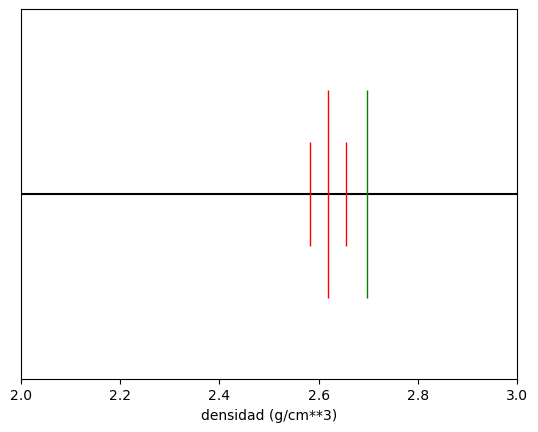

In [111]:
a = [rho*1000]      # Para representar mi valor medio medido
ua= [rho*1000-urho*1000,rho*1000+urho*1000]          # Para representar mi límite de incertidumbre a 1 sigma del valor medio
b = [2.6984]        # Para representar el valor de referencia

plt.xlim(2,3)       # Límites en los que quiero representar mi eje de densidades en g/cm**3

plt.xlabel("densidad (g/cm**3)")        # Etiqueta y unidades del eje

plt.hlines(0,0,3, colors='0')  # Draw a black horizontal line
plt.ylim(-1,1)
ya = np.zeros(np.shape(a))   # Make all y values the same
yua = np.zeros(np.shape(ua))   # Make all y values the same
yb = np.zeros(np.shape(b))   # Make all y values the same
plt.plot(a,ya,'|',ms = 150, color='r')  # Plot a line at each location specified in a
plt.plot(ua,yua,'|',ms = 75, color='r')  # Plot a line at each location specified in a
plt.plot(b,yb,'|',ms = 150, color='g')  # Plot a line at each location specified in a
plt.yticks([])
plt.show()